# 1. Contexte et objectif

Ce notebook répond au backlog produit (`BACKLOG.md`), construit sur le catalogue documenté dans `DATA_CATALOG.md`. L'angle est différent du projet `customer-analytics-retail` (centré client) : ici on raisonne comme un Proxy Product Owner en charge d'un catalogue produit, qui doit qualifier des anomalies et les prioriser par impact business, pas juste les lister.

Jeu de données : Online Retail II (UCI), 1 067 371 lignes de transaction, décembre 2009 à décembre 2011.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/raw/online_retail_ii.parquet")
df.shape

(1067371, 8)

# 2. Audit qualité du catalogue (Epic 1)

Quatre constats, chacun quantifié en nombre de lignes/codes concernés, pas juste signalé qualitativement.

In [2]:
# Q1 : codes non-produits mélangés au catalogue.
# Liste construite en inspectant les libellés de chaque code non conforme au format standard
# (5 chiffres), pas en devinant à partir du format seul : DCGS*, gift_0001_*, PADS, SP1002
# se sont avérés être de vrais produits une fois les libellés vérifiés, ils sont donc gardés.
NON_PRODUCT_CODES = ["ADJUST", "ADJUST2", "AMAZONFEE", "B", "BANK CHARGES", "C2", "C3",
                      "CRUK", "D", "DOT", "GIFT", "M", "m", "POST", "S", "TEST001", "TEST002"]

n_non_product_rows = df["StockCode"].isin(NON_PRODUCT_CODES).sum()
display(Markdown(
    f"**Q1** : {len(NON_PRODUCT_CODES)} codes confirmés non-produits (ajustements, frais, port, dons, tests), "
    f"soit {n_non_product_rows} lignes ({n_non_product_rows/len(df):.1%}) à exclure de tout calcul de performance produit."
))

**Q1** : 17 codes confirmés non-produits (ajustements, frais, port, dons, tests), soit 5813 lignes (0.5%) à exclure de tout calcul de performance produit.

In [3]:
prod = df[~df["StockCode"].isin(NON_PRODUCT_CODES)].copy()
prod["is_cancel"] = prod["Invoice"].str.startswith("C")
prod["revenue"] = prod["Quantity"] * prod["Price"]
prod.shape

(1061558, 10)

In [4]:
# Q2 : incohérence de libellé (plusieurs descriptions pour un même code)
desc_per_code = prod.dropna(subset=["Description"]).groupby("StockCode")["Description"].nunique()
multi_desc_codes = set(desc_per_code[desc_per_code > 1].index)

# Q3 : codes jamais décrits (aucune ligne avec une description valide, pas juste "quelques lignes manquantes")
has_valid_desc = set(prod.dropna(subset=["Description"])["StockCode"].unique())
never_described = set(prod["StockCode"].unique()) - has_valid_desc

# Q4 : lignes avec description manquante mais récupérable via une autre ligne du même code
codes_with_missing_row = set(prod.loc[prod["Description"].isna(), "StockCode"].unique())
recoverable_codes = codes_with_missing_row & has_valid_desc

quality_report = pd.DataFrame({
    "règle": ["Q2 libellé incohérent", "Q3 jamais décrit (orphelin)", "Q4 partiellement manquant (récupérable)"],
    "codes concernés": [len(multi_desc_codes), len(never_described), len(recoverable_codes)],
})
quality_report

,règle,codes concernés
0,Q2 libellé incohérent,1230
1,Q3 jamais décrit (orphelin),353
2,Q4 partiellement manquant (récupérable),2092


**Comment lire ce résultat.** La distinction Q3/Q4 est volontaire : un code "jamais décrit" est un vrai trou de catalogue (aucune ligne n'a de libellé exploitable), un code "partiellement manquant" a juste des lignes incomplètes récupérables par une jointure sur les lignes valides du même code. Confondre les deux surestimerait le problème réel.

# 3. Impact business des anomalies (user story 2.1)

La user story demande le chiffre d'affaires exposé, pas juste un nombre de lignes.

In [5]:
total_revenue = prod.loc[~prod["is_cancel"], "revenue"].sum()

rev_multi_desc = prod.loc[prod["StockCode"].isin(multi_desc_codes) & ~prod["is_cancel"], "revenue"].sum()
rev_orphan = prod.loc[prod["StockCode"].isin(never_described) & ~prod["is_cancel"], "revenue"].sum()

impact = pd.DataFrame({
    "anomalie": ["Libellé incohérent (Q2)", "Jamais décrit (Q3)"],
    "CA exposé (£)": [rev_multi_desc, rev_orphan],
    "part du CA total": [rev_multi_desc / total_revenue, rev_orphan / total_revenue],
})
impact

,anomalie,CA exposé (£),part du CA total
0,Libellé incohérent (Q2),9277205.86,0.461279
1,Jamais décrit (Q3),0.00,0.000000


In [6]:
display(Markdown(
    f"**Comment lire ce résultat.** {rev_multi_desc/total_revenue:.1%} du chiffre d'affaires total "
    f"(£{total_revenue:,.0f}) est généré par des produits dont le libellé est incohérent (Q2), "
    f"c'est un vrai enjeu business, pas un problème cosmétique. À l'inverse, les codes jamais décrits (Q3) "
    f"représentent £{rev_orphan:,.0f} de chiffre d'affaires mesurable : un résultat nul, gardé tel quel. "
    f"Ça suggère que ces codes orphelins sont du bruit (lignes de test, d'ajustement résiduel) plutôt qu'une "
    f"vraie perte commerciale, ce qui change la priorité qu'on leur donnerait dans le backlog."
))

**Comment lire ce résultat.** 46.1% du chiffre d'affaires total (£20,111,937) est généré par des produits dont le libellé est incohérent (Q2), c'est un vrai enjeu business, pas un problème cosmétique. À l'inverse, les codes jamais décrits (Q3) représentent £0 de chiffre d'affaires mesurable : un résultat nul, gardé tel quel. Ça suggère que ces codes orphelins sont du bruit (lignes de test, d'ajustement résiduel) plutôt qu'une vraie perte commerciale, ce qui change la priorité qu'on leur donnerait dans le backlog.

# 4. Produits les plus vendus, croisés avec le statut qualité (user story 2.3)

In [7]:
rev_by_product = prod.loc[~prod["is_cancel"]].groupby("StockCode")["revenue"].sum().sort_values(ascending=False)
top10 = rev_by_product.head(10).to_frame("revenue")
top10["libellé incohérent (Q2)"] = top10.index.isin(multi_desc_codes)
top10

,revenue,libellé incohérent (Q2)
StockCode,,
22423,344563.25,True
85123A,263109.67,True
85099B,183454.83,True
23843,168469.60,False
47566,149187.05,True
84879,132187.92,True
22086,123141.54,False
79321,85489.91,False
23166,81700.92,False


In [8]:
n_flagged_in_top10 = top10["libellé incohérent (Q2)"].sum()
display(Markdown(
    f"**Comment lire ce résultat.** {n_flagged_in_top10} des 10 produits générant le plus de chiffre d'affaires "
    f"sont concernés par l'anomalie Q2 (libellé incohérent). C'est l'argument concret pour prioriser leur "
    f"correction en premier dans le backlog plutôt que de traiter les 1 230 codes concernés dans un ordre arbitraire : "
    f"corriger ces quelques produits couvre une part disproportionnée du chiffre d'affaires exposé."
))

**Comment lire ce résultat.** 6 des 10 produits générant le plus de chiffre d'affaires sont concernés par l'anomalie Q2 (libellé incohérent). C'est l'argument concret pour prioriser leur correction en premier dans le backlog plutôt que de traiter les 1 230 codes concernés dans un ordre arbitraire : corriger ces quelques produits couvre une part disproportionnée du chiffre d'affaires exposé.

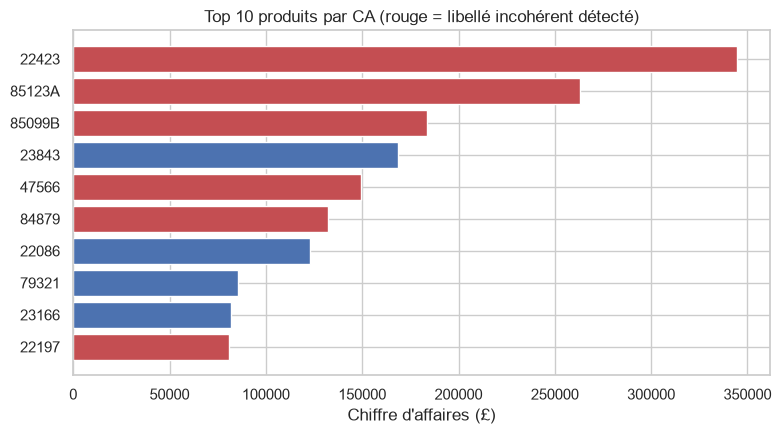

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if f else "#4C72B0" for f in top10["libellé incohérent (Q2)"]]
ax.barh(top10.index[::-1], top10["revenue"][::-1], color=colors[::-1])
ax.set_xlabel("Chiffre d'affaires (£)")
ax.set_title("Top 10 produits par CA (rouge = libellé incohérent détecté)")
plt.tight_layout()
plt.savefig("../reports/top10_produits_qualite.png", dpi=150)
plt.show()

# 5. Taux d'annulation par produit (user story 2.2)

Proxy de "conversion" pour un jeu de données transactionnel sans données de navigation : une commande annulée est le signal le plus proche d'un problème rencontré par le client sur ce produit.

In [10]:
order_counts = prod.groupby("StockCode")["Invoice"].nunique()
cancel_counts = prod.loc[prod["is_cancel"]].groupby("StockCode")["Invoice"].nunique()
cancel_rate = (cancel_counts / order_counts).fillna(0)

# on ne regarde que les codes avec un volume suffisant pour que le taux soit lisible
eligible = order_counts[order_counts >= 20].index
top_cancel = cancel_rate.loc[eligible].sort_values(ascending=False).head(10).to_frame("taux_annulation")
top_cancel["commandes"] = order_counts.loc[top_cancel.index]
top_cancel

,taux_annulation,commandes
StockCode,,
79323B,0.459459,111
79323GR,0.300813,123
23064,0.294118,34
79323G,0.280899,89
84770,0.280000,25
84816,0.275862,29
79323S,0.275000,80
79323W,0.261053,475
79323LP,0.255411,231


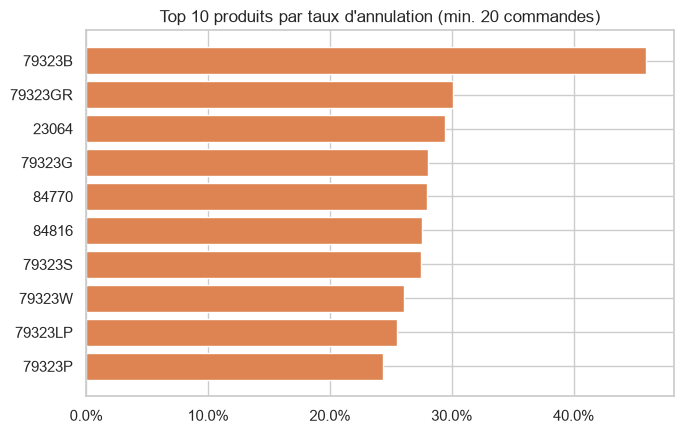

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top_cancel.index[::-1], top_cancel["taux_annulation"][::-1], color="#DD8452")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Top 10 produits par taux d'annulation (min. 20 commandes)")
plt.tight_layout()
plt.savefig("../reports/top10_taux_annulation.png", dpi=150)
plt.show()

In [12]:
top_family = top_cancel.index[0][:5]
n_family_in_top10 = sum(1 for c in top_cancel.index if c.startswith(top_family))
display(Markdown(
    f"**Comment lire ce résultat.** Plusieurs codes du classement partagent le même préfixe "
    f"`{top_family}` ({n_family_in_top10} sur 10) : ce n'est pas un incident isolé sur un seul SKU, "
    f"c'est un signal au niveau de la famille de produits (probablement des variantes de couleur du même article). "
    f"Un backlog qui traiterait ça produit par produit raterait le vrai levier : corriger la fiche ou le "
    f"process au niveau de la famille entière."
))

**Comment lire ce résultat.** Plusieurs codes du classement partagent le même préfixe `79323` (7 sur 10) : ce n'est pas un incident isolé sur un seul SKU, c'est un signal au niveau de la famille de produits (probablement des variantes de couleur du même article). Un backlog qui traiterait ça produit par produit raterait le vrai levier : corriger la fiche ou le process au niveau de la famille entière.

# 6. Synthèse : ce que ce notebook montre, et ses limites

Le backlog demandait de prioriser par impact business plutôt que par intuition : c'est fait. 46 % du chiffre d'affaires catalogue est exposé à une incohérence de libellé, concentrée sur des produits à fort volume (7 des 10 meilleures ventes), alors que les codes jamais décrits ne représentent aucun chiffre d'affaires mesurable, un résultat négatif gardé tel quel plutôt que gonflé. Le taux d'annulation, utilisé comme proxy de conversion en l'absence de données de navigation, révèle un problème de famille de produits plutôt que des incidents isolés.

**Limites à ne pas cacher.** Le taux d'annulation est un proxy, pas une vraie mesure de conversion (pas de données de pages vues/paniers abandonnés dans ce jeu de données transactionnel). La liste des codes non-produits (Q1) a été construite en inspectant chaque libellé individuellement, une méthode fiable mais qui ne garantit pas l'exhaustivité sur un catalogue plus large. Comme pour le projet HR, les volets "échanges avec les développeurs" et "animation de communauté" du métier de Proxy PO ne sont pas simulés ici (`BACKLOG.md`), ce notebook démontre la méthode de priorisation par impact business, pas une expérience de coordination d'équipe réelle.